In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('data/raw/ADNIMERGE.csv')
print(df.shape)
print(df['DX'].value_counts())
df.head()

(14314, 9)
DX
MCI         5665
CN          4981
Dementia    2642
Name: count, dtype: int64


,RID,VISCODE,MMSE,DX,Hippocampus,Gender,Education,APOE4,visit_num
0,1.0,bl,28.0,NaN,NaN,Female,18.0,NaN,0.0
1,2.0,bl,28.0,CN,NaN,Male,16.0,0.0,0.0
2,2.0,m06,28.0,CN,NaN,Male,16.0,0.0,1.0
3,2.0,m36,29.0,CN,NaN,Male,16.0,0.0,5.0
4,2.0,m60,28.0,CN,NaN,Male,16.0,0.0,7.0


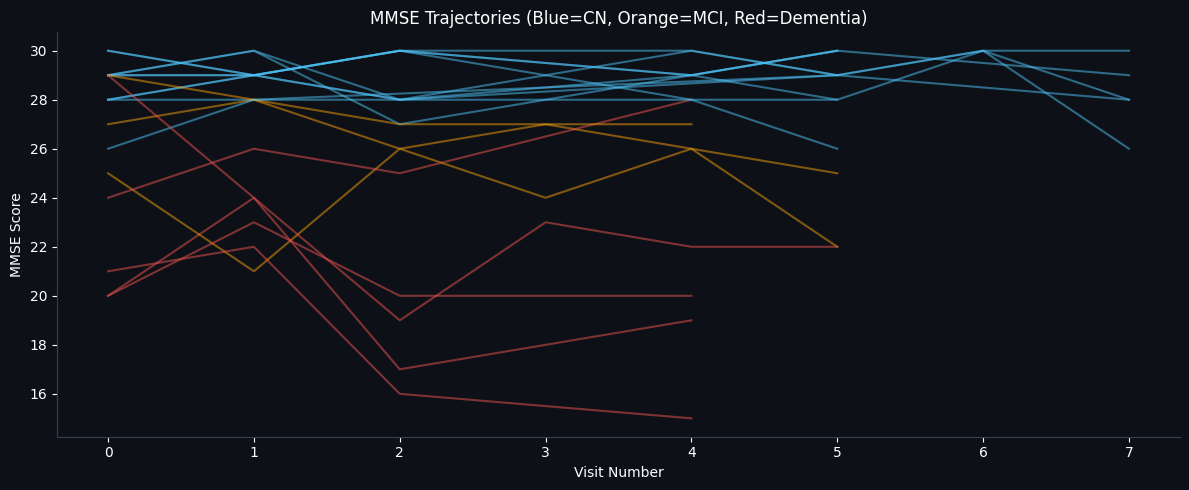

In [2]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = {'CN': '#4fc3f7', 'MCI': '#f59e0b', 'Dementia': '#ef5350'}

sample_ids = df['RID'].dropna().unique()[:30]
for rid in sample_ids:
    patient = df[df['RID'] == rid].dropna(subset=['visit_num', 'MMSE']).sort_values('visit_num')
    if len(patient) >= 2:
        dx = patient['DX'].iloc[-1]
        color = colors.get(dx, '#64748b')
        ax.plot(patient['visit_num'], patient['MMSE'], alpha=0.5, linewidth=1.5, color=color)

ax.set_facecolor('#0d1117')
fig.patch.set_facecolor('#0d1117')
ax.set_xlabel('Visit Number', color='white')
ax.set_ylabel('MMSE Score', color='white')
ax.set_title('MMSE Trajectories (Blue=CN, Orange=MCI, Red=Dementia)', color='white')
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('#334155')
ax.spines['left'].set_color('#334155')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [3]:
converters = []
for rid, group in df.dropna(subset=['DX', 'visit_num']).groupby('RID'):
    group = group.sort_values('visit_num')
    dx_list = group['DX'].tolist()
    if dx_list[0] == 'MCI' and 'Dementia' in dx_list:
        mmse_start = group['MMSE'].iloc[0]
        mmse_end = group['MMSE'].iloc[-1]
        mmse_drop = mmse_start - mmse_end
        converters.append({
            'RID': int(rid),
            'n_visits': len(group),
            'mmse_start': mmse_start,
            'mmse_end': mmse_end,
            'mmse_drop': mmse_drop,
            'APOE4': group['APOE4'].iloc[0]
        })

converters_df = pd.DataFrame(converters).sort_values('mmse_drop', ascending=False)
print(f"Total MCI→Dementia converters: {len(converters_df)}")
print(f"\nTop 10 most dramatic progressors:")
print(converters_df.head(10).to_string(index=False))

Total MCI→Dementia converters: 185

Top 10 most dramatic progressors:
 RID  n_visits  mmse_start  mmse_end  mmse_drop  APOE4
 750         5        27.0       8.0       19.0    1.0
 667         7        28.0       9.0       19.0    1.0
1282         7        26.0       7.0       19.0    0.0
  50         6        26.0       8.0       18.0    0.0
 128         8        29.0      11.0       18.0    2.0
1394         6        27.0      11.0       16.0    1.0
 695         7        25.0       9.0       16.0    1.0
 834         7        26.0      10.0       16.0    1.0
 631         6        25.0      10.0       15.0    1.0
 388         7        25.0      11.0       14.0    2.0


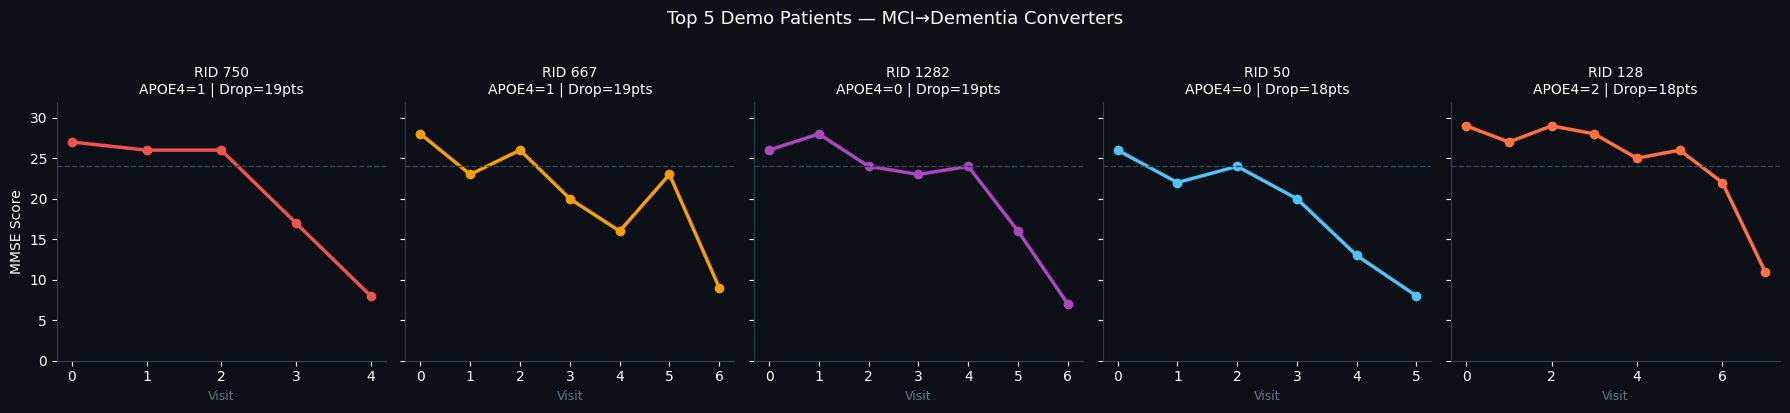

 RID  n_visits  mmse_start  mmse_end  mmse_drop  APOE4
 750         5        27.0       8.0       19.0    1.0
 667         7        28.0       9.0       19.0    1.0
1282         7        26.0       7.0       19.0    0.0
  50         6        26.0       8.0       18.0    0.0
 128         8        29.0      11.0       18.0    2.0


In [4]:
demo_rids = [750, 667, 1282, 50, 128]
colors_map = {750: '#ef5350', 667: '#f59e0b', 1282: '#ab47bc', 50: '#4fc3f7', 128: '#ff7043'}

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
fig.patch.set_facecolor('#0d1117')

for ax, rid in zip(axes, demo_rids):
    patient = df[df['RID'] == rid].dropna(subset=['visit_num', 'MMSE']).sort_values('visit_num')
    apoe = patient['APOE4'].iloc[0]
    
    ax.set_facecolor('#0d1117')
    ax.plot(patient['visit_num'], patient['MMSE'], 
            color=colors_map[rid], linewidth=2.5, marker='o', markersize=6)
    ax.axhline(y=24, color='#334155', linestyle='--', linewidth=1)
    ax.set_title(f'RID {rid}\nAPOE4={int(apoe) if not pd.isna(apoe) else "?"} | Drop={patient["MMSE"].iloc[0]-patient["MMSE"].iloc[-1]:.0f}pts', 
                 color='white', fontsize=10)
    ax.set_xlabel('Visit', color='#64748b', fontsize=9)
    ax.tick_params(colors='white')
    ax.spines['bottom'].set_color('#334155')
    ax.spines['left'].set_color('#334155')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, 32)

axes[0].set_ylabel('MMSE Score', color='white')
fig.suptitle('Top 5 Demo Patients — MCI→Dementia Converters', color='white', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Save demo patient list
demo_df = converters_df[converters_df['RID'].isin(demo_rids)]
print(demo_df.to_string(index=False))

In [5]:
# ── Sequence Builder ──────────────────────────────────────────
FEATURE_COLS = ['MMSE', 'Hippocampus', 'Education', 'APOE4']
VISIT_ORDER  = {'bl':0,'m06':1,'m12':2,'m18':3,'m24':4,'m36':5,'m48':6,'m60':7}

# Fill missing hippocampus with mean
df['Hippocampus'] = df['Hippocampus'].fillna(df['Hippocampus'].mean())
df['APOE4']       = df['APOE4'].fillna(df['APOE4'].median())
df['Education']   = df['Education'].fillna(df['Education'].median())
df['Gender_num']  = (df['Gender'] == 'Male').astype(float)

FEATURE_COLS = ['MMSE', 'Hippocampus', 'Education', 'APOE4', 'Gender_num']

sequences = []
for rid, group in df.dropna(subset=['MMSE', 'visit_num']).groupby('RID'):
    group = group.sort_values('visit_num')
    
    # Need at least 3 visits with MMSE
    if len(group) < 3:
        continue
    
    features = group[FEATURE_COLS].values   # shape (T, 5)
    mmse_vals = group['MMSE'].values
    dx_vals   = group['DX'].fillna('Unknown').values
    
    # For each possible prediction window
    for t in range(2, len(group)):
        X_seq  = features[:t]              # all visits up to t
        y      = mmse_vals[t]              # predict MMSE at visit t
        sequences.append({
            'RID':       rid,
            'sequence':  X_seq,
            'target':    y,
            'n_steps':   t,
            'final_dx':  dx_vals[t],
            'baseline_dx': dx_vals[0],
        })

print(f"Total training sequences: {len(sequences)}")
print(f"Example sequence shape:   {sequences[0]['sequence'].shape}")
print(f"Example target (MMSE):    {sequences[0]['target']}")
print(f"\nDX distribution in sequences:")
import collections
dx_counts = collections.Counter(s['final_dx'] for s in sequences)
print(dict(dx_counts))

Total training sequences: 2475
Example sequence shape:   (2, 5)
Example target (MMSE):    29.0

DX distribution in sequences:
{'CN': 754, 'Dementia': 792, 'MCI': 928, 'Unknown': 1}


Ridge  MAE: 1.650
Ridge  R²:  0.733

XGB    MAE: 1.606
XGB    R²:  0.730


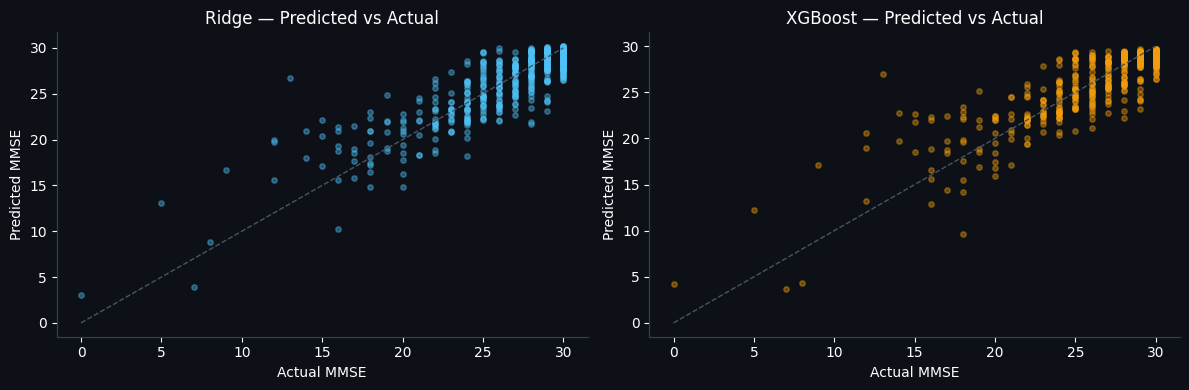

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb

# Flatten sequences — use last known visit features to predict next MMSE
X = np.array([s['sequence'][-1] for s in sequences])  # last visit features
y = np.array([s['target'] for s in sequences])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Ridge baseline
ridge = Ridge()
ridge.fit(X_train_s, y_train)
ridge_preds = ridge.predict(X_test_s)
print(f"Ridge  MAE: {mean_absolute_error(y_test, ridge_preds):.3f}")
print(f"Ridge  R²:  {r2_score(y_test, ridge_preds):.3f}")

# XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
print(f"\nXGB    MAE: {mean_absolute_error(y_test, xgb_preds):.3f}")
print(f"XGB    R²:  {r2_score(y_test, xgb_preds):.3f}")

# Plot predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0d1117')

for ax, preds, name, color in zip(axes, [ridge_preds, xgb_preds], ['Ridge', 'XGBoost'], ['#4fc3f7', '#f59e0b']):
    ax.set_facecolor('#0d1117')
    ax.scatter(y_test, preds, alpha=0.4, s=15, color=color)
    ax.plot([0, 30], [0, 30], color='#475569', linestyle='--', linewidth=1)
    ax.set_xlabel('Actual MMSE', color='white')
    ax.set_ylabel('Predicted MMSE', color='white')
    ax.set_title(f'{name} — Predicted vs Actual', color='white')
    ax.tick_params(colors='white')
    for spine in ['bottom','left']: ax.spines[spine].set_color('#334155')
    for spine in ['top','right']:   ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()